In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
import time
#PATH PROCESS
import os
import os.path
from pathlib import Path
import glob
#from scipy.io import loadmat
#import nibabel as nib
#IMAGE PROCESS
import cv2
from PIL import Image
#from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from scipy.ndimage.filters import convolve
from skimage import data, io, filters
import skimage
from skimage.morphology import convex_hull_image, erosion
from IPython import display
from scipy.ndimage import gaussian_filter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
#SCALER & TRANSFORMATION
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
#from keras import regularizers
from sklearn.preprocessing import LabelEncoder
#ACCURACY CONTROL
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
#OPTIMIZER
#All tensorflow utilities for creating, training and working with a CNN
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
#IGNORING WARNINGS
from warnings import filterwarnings
filterwarnings("ignore",category=DeprecationWarning)
filterwarnings("ignore", category=FutureWarning)
filterwarnings("ignore", category=UserWarning)

/tmp/ipython-input-1-2072887171.py:21: DeprecationWarning: Please import `convolve` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import convolve


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
"/content/gdrive/MyDrive/data/Task02_Heart/Task02_Heart/imagesTr"

'/content/gdrive/MyDrive/data/Task02_Heart/Task02_Heart/imagesTr'

In [ ]:
!pip install --upgrade nibabel

In [ ]:
import nibabel as nib

In [ ]:
example_image = nib.load("/content/gdrive/MyDrive/data/Task02_Heart/Task02_Heart/imagesTr/la_003.nii.gz")
example_label = nib.load("/content/gdrive/MyDrive/data/Task02_Heart/Task02_Heart/labelsTr/la_003.nii.gz")

In [ ]:
data = example_image.get_fdata()

In [ ]:
Example_ALL_Images = example_image.get_fdata()
Example_ALL_Labels = example_label.get_fdata()

In [ ]:
print(Example_ALL_Images[0].shape)
print(Example_ALL_Labels[0].shape)

(320, 130)
(320, 130)


In [ ]:
print(Example_ALL_Images[Example_ALL_Images.shape[0]//2].shape)

(320, 130)


In [ ]:
print(Example_ALL_Images.shape[0]//2)

160


In [ ]:
print(Example_ALL_Images[Example_ALL_Images.shape[0]//2])

[[  0.   0.   0. ... 246. 342. 326.]
 [  0.   0.   0. ... 401. 379. 276.]
 [  0.   0.   0. ... 356. 309. 259.]
 ...
 [  0.   0.   0. ... 624. 383. 160.]
 [  0.   0.   0. ... 589. 423. 260.]
 [  0.   0.   0. ... 495. 420. 335.]]


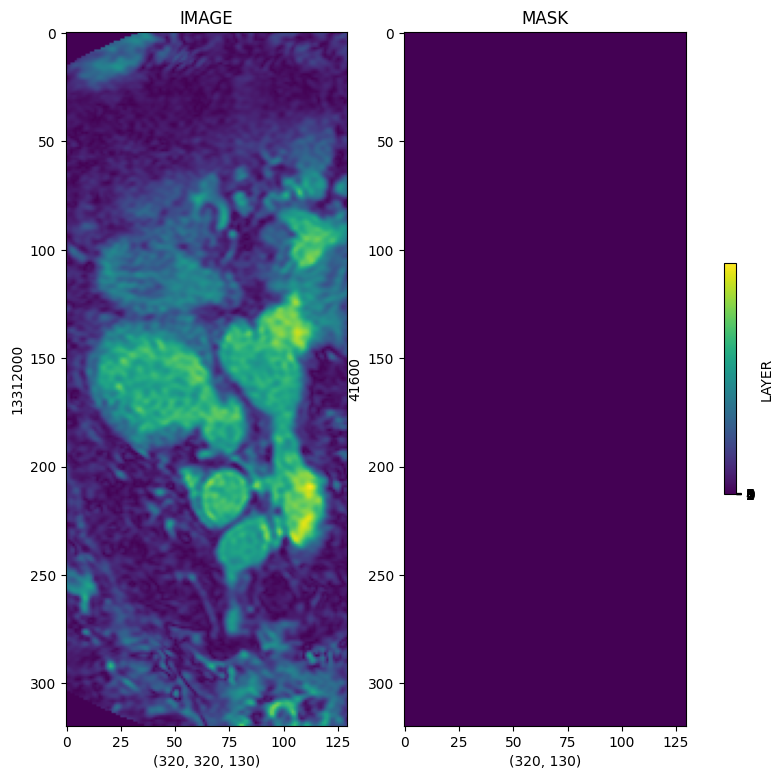

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

figure, axis = plt.subplots(1, 2, figsize=(10, 10))

Plot_Color_Op = axis[0].imshow(Example_ALL_Images[Example_ALL_Images.shape[0]//2])
axis[0].set_xlabel(str(Example_ALL_Images.shape))
axis[0].set_ylabel(str(Example_ALL_Images.size))
axis[0].set_title("IMAGE")

axis[1].imshow(Example_ALL_Labels[Example_ALL_Images.shape[0]//2])
axis[1].set_xlabel(str(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].shape))
axis[1].set_ylabel(str(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].size))
axis[1].set_title("MASK")

figure.colorbar(Plot_Color_Op, ax=axis.ravel().tolist(), shrink=0.3, ticks=range(10), label='LAYER')

plt.show()

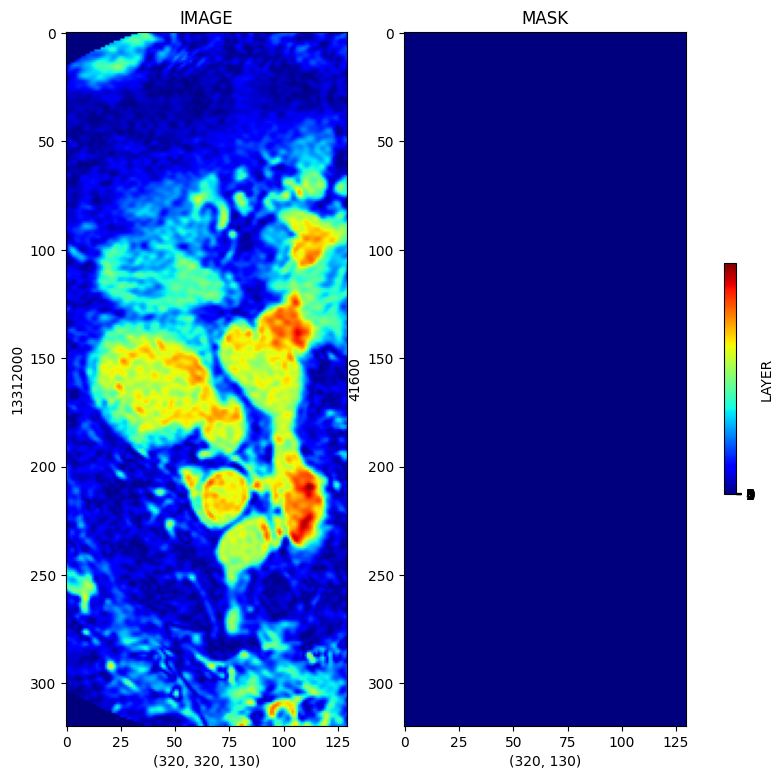

In [ ]:
figure,axis = plt.subplots(1,2,figsize=(10,10))

Plot_Color_Op = axis[0].imshow(Example_ALL_Images[Example_ALL_Images.shape[0]//2],cmap="jet")
axis[0].set_xlabel(Example_ALL_Images.shape)
axis[0].set_ylabel(Example_ALL_Images.size)
axis[0].set_title("IMAGE")

axis[1].imshow(Example_ALL_Labels[Example_ALL_Images.shape[0]//2],cmap="jet")
axis[1].set_xlabel(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].shape)
axis[1].set_ylabel(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].size)
axis[1].set_title("MASK")

figure.colorbar(Plot_Color_Op, ax=axis.ravel().tolist(), shrink=0.3, ticks=range(10),label='LAYER')

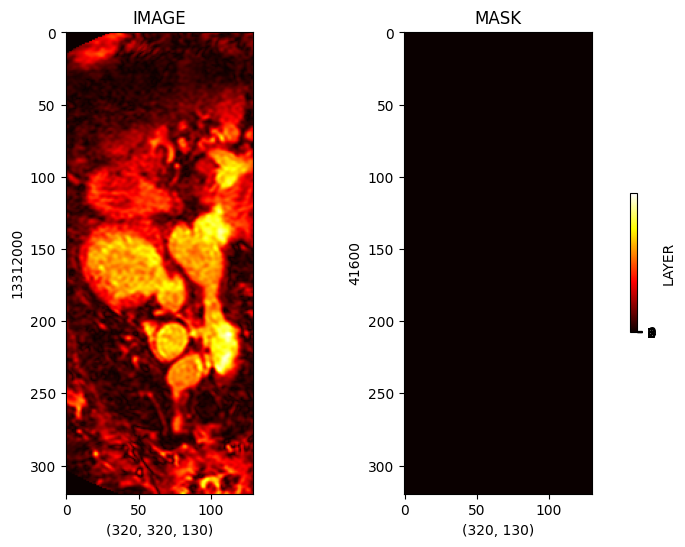

In [ ]:
figure,axis = plt.subplots(1,2,figsize=(10,6))

Plot_Color_Op = axis[0].imshow(Example_ALL_Images[Example_ALL_Images.shape[0]//2],cmap="hot")
axis[0].set_xlabel(Example_ALL_Images.shape)
axis[0].set_ylabel(Example_ALL_Images.size)
axis[0].set_title("IMAGE")

axis[1].imshow(Example_ALL_Labels[Example_ALL_Images.shape[0]//2],cmap="hot")
axis[1].set_xlabel(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].shape)
axis[1].set_ylabel(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].size)
axis[1].set_title("MASK")

figure.colorbar(Plot_Color_Op, ax=axis.ravel().tolist(), shrink=0.3, ticks=range(10),label='LAYER')

In [ ]:
len(Example_ALL_Labels)

320

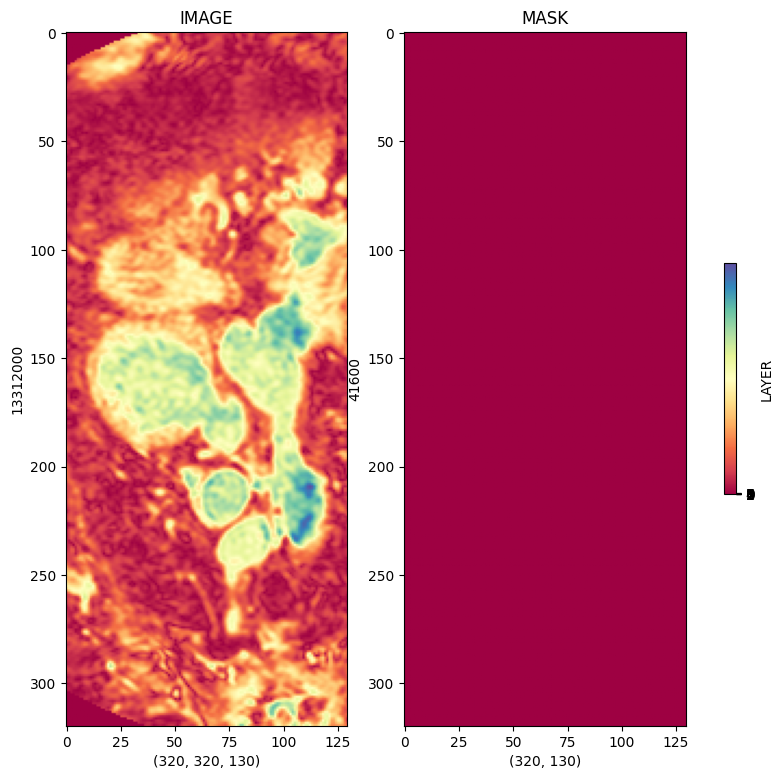

In [ ]:
figure,axis = plt.subplots(1,2,figsize=(10,10))

Plot_Color_Op = axis[0].imshow(Example_ALL_Images[Example_ALL_Images.shape[0]//2],cmap="Spectral")
axis[0].set_xlabel(Example_ALL_Images.shape)
axis[0].set_ylabel(Example_ALL_Images.size)
axis[0].set_title("IMAGE")

axis[1].imshow(Example_ALL_Labels[Example_ALL_Images.shape[0]//2],cmap="Spectral")
axis[1].set_xlabel(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].shape)
axis[1].set_ylabel(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].size)
axis[1].set_title("MASK")

figure.colorbar(Plot_Color_Op, ax=axis.ravel().tolist(), shrink=0.3, ticks=range(10),label='LAYER')

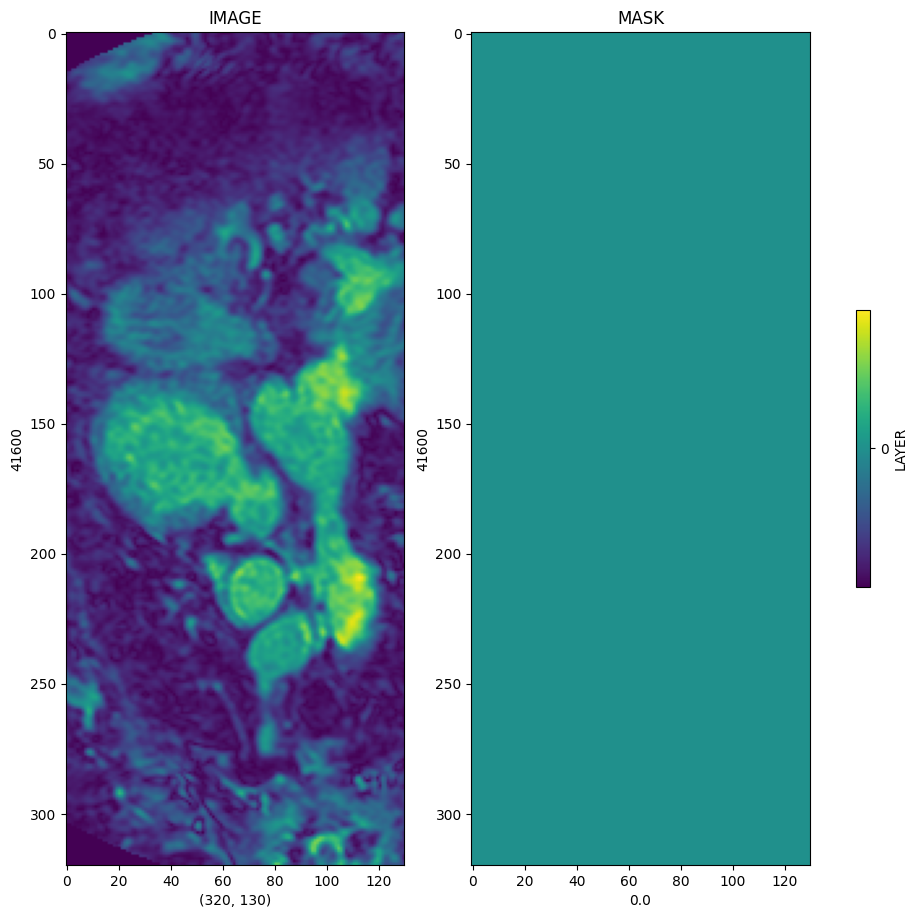

In [ ]:
figure,axis = plt.subplots(1,2,figsize=(12,12))

Picking_Example_IMG = Example_ALL_Images[Example_ALL_Images.shape[0]//2] / 255.
Picking_Example_Label = Example_ALL_Labels[Example_ALL_Images.shape[0]//2] / 255.

axis[0].imshow(Picking_Example_IMG)
axis[0].set_xlabel(Picking_Example_IMG.shape)
axis[0].set_ylabel(Picking_Example_IMG.size)
axis[0].set_title("IMAGE")

Plot_Color_Op = axis[1].imshow(Picking_Example_Label)
axis[1].set_xlabel(np.mean(Picking_Example_Label))
axis[1].set_ylabel(Picking_Example_Label.size)
axis[1].set_title("MASK")

figure.colorbar(Plot_Color_Op, ax=axis.ravel().tolist(), shrink=0.3, ticks=range(10),label='LAYER')

In [ ]:
images_data = list(Path("/content/gdrive/MyDrive/data/Task02_Heart/Task02_Heart/imagesTr/").glob(r"*.nii.gz"))
labels = list(Path("/content/gdrive/MyDrive/data/Task02_Heart/Task02_Heart/labelsTr/").glob(r"*.nii.gz"))

In [ ]:
print(len(images_data))
print(len(labels))

21
22


In [ ]:
images_series = pd.Series(images_data, name="image").astype(str)
labels_series = pd.Series(labels, name="label").astype(str)

In [ ]:
df = pd.concat([images_series, labels_series], axis=1)

In [ ]:
df

,image,label
0,/content/gdrive/MyDrive/data/Task02_Heart/Task...,/content/gdrive/MyDrive/data/Task02_Heart/Task...
1,/content/gdrive/MyDrive/data/Task02_Heart/Task...,/content/gdrive/MyDrive/data/Task02_Heart/Task...
2,/content/gdrive/MyDrive/data/Task02_Heart/Task...,/content/gdrive/MyDrive/data/Task02_Heart/Task...
3,/content/gdrive/MyDrive/data/Task02_Heart/Task...,/content/gdrive/MyDrive/data/Task02_Heart/Task...
4,/content/gdrive/MyDrive/data/Task02_Heart/Task...,/content/gdrive/MyDrive/data/Task02_Heart/Task...
5,/content/gdrive/MyDrive/data/Task02_Heart/Task...,/content/gdrive/MyDrive/data/Task02_Heart/Task...
6,/content/gdrive/MyDrive/data/Task02_Heart/Task...,/content/gdrive/MyDrive/data/Task02_Heart/Task...
7,/content/gdrive/MyDrive/data/Task02_Heart/Task...,/content/gdrive/MyDrive/data/Task02_Heart/Task...
8,/content/gdrive/MyDrive/data/Task02_Heart/Task...,/content/gdrive/MyDrive/data/Task02_Heart/Task...
9,/content/gdrive/MyDrive/data/Task02_Heart/Task...,/content/gdrive/MyDrive/data/Task02_Heart/Task...


In [ ]:
import os

# 0) Drop any rows where image or label is NaN
df = df[df['image'].notna() & df['label'].notna()].reset_index(drop=True)

# 1) Keep only rows whose basenames do NOT start with '._'
def is_valid(p):
    return isinstance(p, str) and not os.path.basename(p).startswith('._')

mask = df['image'].apply(is_valid) & df['label'].apply(is_valid)
df = df[mask].reset_index(drop=True)


or_1_0 = []
image_list = []
label_list = []

for i_img, i_mask in zip(df["image"].values, df["label"].values):
    reading_train_nii = nib.load(i_img)
    reading_label_nii = nib.load(i_mask)

    x_images = reading_train_nii.get_fdata()
    x_labels = reading_label_nii.get_fdata()

    selecting_image = x_images[x_images.shape[0]//2] / 255.
    selecting_label = x_labels[x_images.shape[0]//2] / 255.

    if np.mean(selecting_label) > 0:
        or_1_0.append(1)
        selecting_image = selecting_image.astype("float32")
        selecting_label = selecting_label.astype("float32")

        image_list.append(selecting_image)
        label_list.append(selecting_label)
    else:
        or_1_0.append(0)

In [ ]:
for i_img, i_mask in zip(df["image"].values, df["label"].values):
    reading_train_nii = nib.load(i_img)
    reading_label_nii = nib.load(i_mask)

    x_images = reading_train_nii.get_fdata()
    x_labels = reading_label_nii.get_fdata()

    selecting_image = x_images[x_images.shape[0]//2] / 255.
    selecting_label = x_labels[x_images.shape[0]//2] / 255.

    print(np.shape(selecting_image))
    print(np.shape(selecting_label))
    print("---" * 20)

(320, 130)
(320, 130)
------------------------------------------------------------
(320, 110)
(320, 110)
------------------------------------------------------------
(320, 120)
(320, 120)
------------------------------------------------------------
(320, 130)
(320, 130)
------------------------------------------------------------
(320, 100)
(320, 100)
------------------------------------------------------------
(320, 120)
(320, 120)
------------------------------------------------------------
(320, 120)
(320, 120)
------------------------------------------------------------
(320, 120)
(320, 120)
------------------------------------------------------------
(320, 120)
(320, 120)
------------------------------------------------------------
(320, 122)
(320, 90)
------------------------------------------------------------
(320, 100)
(320, 100)
------------------------------------------------------------
(320, 110)
(320, 122)
------------------------------------------------------------
(320,

In [ ]:
print(or_1_0)

[0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
df['target'] = or_1_0

In [ ]:
print(len(image_list))
print(len(label_list))

16
16


In [ ]:
if len(image_list) > 3:
    print(image_list[3].shape)
else:
    print("image_list does not have enough elements")

if len(label_list) > 3:
    print(label_list[3].shape)
else:
    print("label_list does not have enough elements")

(320, 100)
(320, 100)


In [ ]:
if len(image_list) > 0:
    print(type(image_list[0]))
else:
    print("image_list is empty")

if len(label_list) > 0:
    print(type(label_list[0]))
else:
    print("label_list is empty")

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
Testing_Trans = cv2.resize(image_list[8],(256,256))
print(Testing_Trans.shape)

(256, 256)


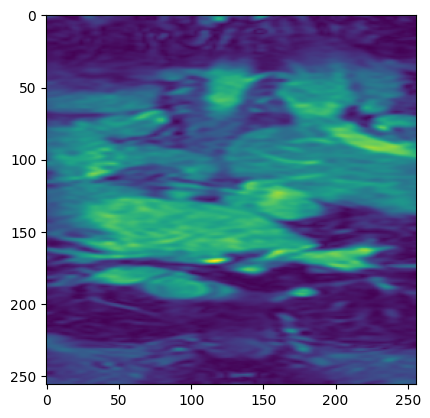

In [ ]:
plt.imshow(Testing_Trans);

In [ ]:
True_Seg = df

In [ ]:
Image_List = []
Label_List = []

for i_img,i_mask in zip(df["image"].values,df["label"].values):

    Reading_Train_NII = nib.load(i_img)
    Reading_Label_NII = nib.load(i_mask)

    X_Images = Reading_Train_NII.get_fdata()
    X_Labels = Reading_Label_NII.get_fdata()

    Selecting_Image = X_Images[X_Images.shape[0]//2] / 255.
    Selecting_Label = X_Labels[X_Images.shape[0]//2] / 255.

    Selecting_Image = Selecting_Image.astype("float32")
    Selecting_Label = Selecting_Label.astype("float32")

    Resized_IMG = cv2.resize(Selecting_Image,(256,256))
    Resized_LABEL = cv2.resize(Selecting_Label,(256,256))

    Image_List.append(Resized_IMG)
    Label_List.append(Resized_LABEL)

In [ ]:
print(len(Image_List))
print(len(Label_List))

18
18


In [ ]:
print(np.shape(np.array(Image_List)))
print(np.shape(np.array(Label_List)))

(18, 256, 256)
(18, 256, 256)


Text(0.5, 1.0, 'MASK')

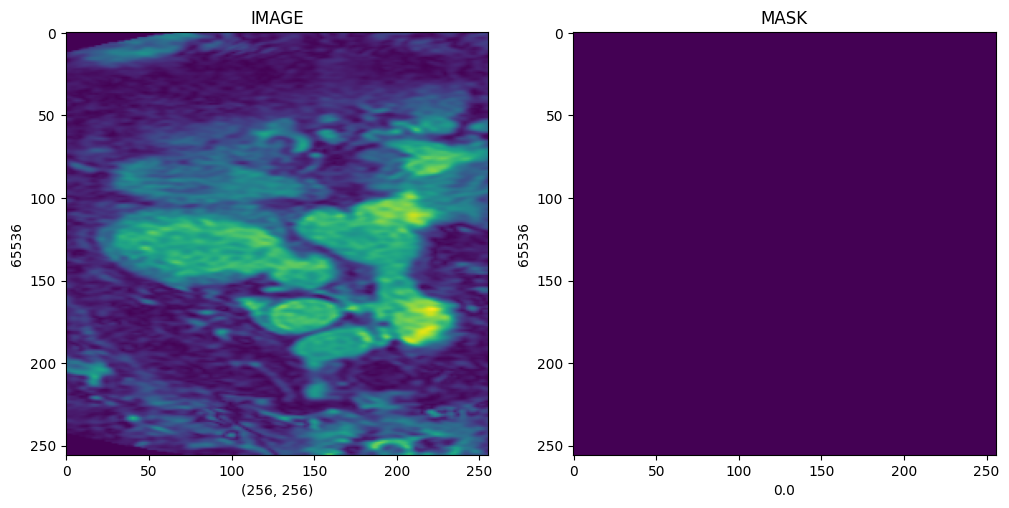

In [ ]:
figure,axis = plt.subplots(1,2,figsize=(12,12))

Picking_Example_IMG = Image_List[0]
Picking_Example_Label = Label_List[0]

axis[0].imshow(Picking_Example_IMG)
axis[0].set_xlabel(Picking_Example_IMG.shape)
axis[0].set_ylabel(Picking_Example_IMG.size)
axis[0].set_title("IMAGE")

axis[1].imshow(Picking_Example_Label)
axis[1].set_xlabel(np.mean(Picking_Example_Label))
axis[1].set_ylabel(Picking_Example_Label.size)
axis[1].set_title("MASK")

In [ ]:
### Coverting image to array
X = np.array(Image_List, dtype="float32")
y = np.array(Label_List,dtype="float32")

In [ ]:
print(X.shape)
print(y.shape)

(18, 256, 256)
(18, 256, 256)


In [ ]:
X_TRAIN = X.reshape(X.shape[0],X.shape[1],X.shape[2],1)
X_LABEL = y.reshape(y.shape[0],y.shape[1],y.shape[2],1)

In [ ]:
Y_TRAIN = df['target']

In [ ]:
print(X_TRAIN.shape)
print(X_LABEL.shape)

(18, 256, 256, 1)
(18, 256, 256, 1)


In [ ]:
print(X_TRAIN[0:-1].shape)

(17, 256, 256, 1)


# Updated Baseline AE Model

In [ ]:
# ── BASELINE AE (unchanged) + PROFILING WRAPPER ──

import time, psutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# (Assume X_TRAIN, X_LABEL already defined)

# 0) Helper to compute FLOPs via TF1 profiler
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
def compute_flops(model, inp_shape, inp_dtype):
    full_model = tf.function(lambda x: model(x))
    concrete  = full_model.get_concrete_function(
        tf.TensorSpec([1, *inp_shape], inp_dtype))
    frozen    = convert_variables_to_constants_v2(concrete)
    graph_def = frozen.graph.as_graph_def()
    with tf.compat.v1.Graph().as_default() as g:
        tf.import_graph_def(graph_def, name='')
        run_meta = tf.compat.v1.RunMetadata()
        opts     = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops    = tf.compat.v1.profiler.profile(
                       graph=g,
                       run_meta=run_meta,
                       cmd='op',
                       options=opts)
    return flops.total_float_ops

# -------------------------------------------------------------------
# 1) Your baseline AE definition — DO NOT MODIFY ANYTHING HERE:
EncoderModel = tf.keras.Sequential([
  tf.keras.layers.Conv2D(32, (5, 5), kernel_initializer='he_normal', use_bias=True, name="ENCODER_INPUT"),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.ReLU(),

  tf.keras.layers.Conv2D(64, (5, 5), kernel_initializer='he_normal', use_bias=True),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.ReLU(),

  tf.keras.layers.Conv2D(128, (2, 2), kernel_initializer='he_normal', use_bias=True),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.ReLU(),

  tf.keras.layers.Conv2D(128, (2, 2), kernel_initializer='he_normal', use_bias=True),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.ReLU(),
])

Decoder = tf.keras.Sequential([
  tf.keras.layers.Conv2DTranspose(128, (2, 2)),
  tf.keras.layers.ReLU(),

  tf.keras.layers.Conv2DTranspose(64, (2, 2)),
  tf.keras.layers.ReLU(),

  tf.keras.layers.Conv2DTranspose(32, (5, 5)),
  tf.keras.layers.ReLU(),

  tf.keras.layers.Conv2DTranspose(1, (5, 5), name="DECODER_OUTPUT"),
])

AE_Structure = Sequential([EncoderModel, Decoder])

AE_Structure.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-7),
    metrics=["accuracy"]
)
# -------------------------------------------------------------------

# 2) Initialize graph (dummy pass)
_ = AE_Structure(tf.zeros((1, *X_TRAIN.shape[1:]), dtype=X_TRAIN.dtype))

# 3) Compute and print FLOPs
flops_base = compute_flops(AE_Structure, X_TRAIN.shape[1:], X_TRAIN.dtype)
print("Baseline AE FLOPs:", flops_base)

# 4) Measure memory before training
proc = psutil.Process()
mem_before = proc.memory_info().rss / (1024**2)
print(f"Memory before training: {mem_before:.2f} MB")

# 5) Set up EarlyStopping
es = EarlyStopping(
    monitor='loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# 6) Train & time it
t0 = time.perf_counter()
history_base = AE_Structure.fit(
    X_TRAIN, X_LABEL,
    epochs=10,
    verbose=1,    # default batch_size=32 (or smaller if X_TRAIN<32)
    callbacks=[es]
)
train_time_base = time.perf_counter() - t0
print(f"Baseline training time: {train_time_base:.2f} s")

# 7) EarlyStopping info
print(f"Configured EarlyStopping patience: {es.patience}")
print(f"EarlyStopping stopped_epoch: {es.stopped_epoch}")
if es.stopped_epoch > 0:
    print(f"Early stopping actually triggered at epoch {es.stopped_epoch + 1}")
else:
    print("Early stopping did NOT trigger (ran full 10 epochs)")

# 8) Measure memory after training
mem_after = proc.memory_info().rss / (1024**2)
print(f"Memory after training: {mem_after:.2f} MB")
print(f"Memory delta: {mem_after - mem_before:.2f} MB")

# 9) Compute & print average training accuracy
avg_acc = np.mean(history_base.history['accuracy'])
epochs_ran = len(history_base.history['accuracy'])
print(f"Average training accuracy over {epochs_ran} epochs: {avg_acc:.4f}")

# 10) Inference time on the entire training set
t_inf0 = time.perf_counter()
recon_train = AE_Structure.predict(X_TRAIN, batch_size=32, verbose=0)
t_inf = time.perf_counter() - t_inf0
print(f"Inference time on training set: {t_inf:.2f} s")



Baseline AE FLOPs: 37043235904
Memory before training: 2019.07 MB
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.9692 - loss: 0.0272
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9692 - loss: 0.0271
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9692 - loss: 0.0271
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9692 - loss: 0.0271
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9692 - loss: 0.0270
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9692 - loss: 0.0270
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9692 - loss: 0.0269
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9692 - loss: 0.0269
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9692 - loss: 0.0269
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9692 - loss: 0.0268
Restoring model weights from the end of the best epoch: 10.
Baseline training time: 113.71 s
Configured

Mean Squared Error (MSE) on training set: 9.0448


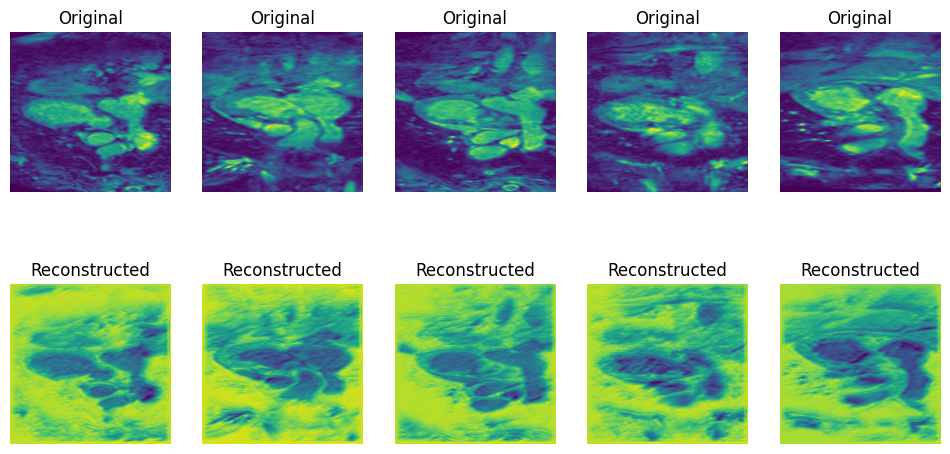

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1) Get predictions (reconstructed images) from the Base Autoencoder model
recon_train = AE_Structure.predict(X_TRAIN, batch_size=32, verbose=0)

# 2) Compute Mean Squared Error (MSE) between original images and reconstructed images
# Flatten the images for MSE calculation (reshape to 2D)
mse_base = mean_squared_error(X_TRAIN.reshape(-1, X_TRAIN.shape[-1]), recon_train.reshape(-1, recon_train.shape[-1]))

# 3) Print MSE
print(f"Mean Squared Error (MSE) on training set: {mse_base:.4f}")

# 4) Visualize some examples of original vs. reconstructed images
num_images = 5  # Number of images to display
plt.figure(figsize=(12, 6))
for i in range(num_images):
    # Plot original image
    ax = plt.subplot(2, num_images, i + 1)
    plt.imshow(X_TRAIN[i])  # Original image
    plt.title("Original")
    plt.axis('off')

    # Plot reconstructed image
    ax = plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(recon_train[i])  # Reconstructed image
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()


In [ ]:
num_classes = df['target'].nunique()
num_classes

2

In [ ]:
## Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an instance of ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10,      # Rotate the images randomly by up to 10 degrees
    width_shift_range=0.1,  # Shift the images horizontally by up to 10% of the total width
    height_shift_range=0.1, # Shift the images vertically by up to 10% of the total height
    shear_range=0.1,        # Apply shear transformation to the images
    zoom_range=0.1,         # Zoom in or out on the images by up to 10%
    horizontal_flip=True,   # Flip the images horizontally
    vertical_flip=True     # Flip the images vertically
)

# Define the number of augmented images that wanted to generate
num_augmented_images = 10

# Generate augmented images and labels
augmented_images = []
augmented_labels = []

for i in range(X_TRAIN.shape[0]):
    image = X_TRAIN[i]
    label = X_LABEL[i]

    # Reshape the image and label for augmentation
    image = np.reshape(image, (1,) + image.shape)
    label = np.reshape(label, (1,) + label.shape)

    # Generate augmented images and labels
    aug_images = datagen.flow(image, batch_size=1, shuffle=False)
    aug_labels = datagen.flow(label, batch_size=1, shuffle=False)

    # Save the augmented images and labels
    for j in range(num_augmented_images):
       augmented_images.append(next(aug_images)[0])
       augmented_labels.append(next(aug_labels)[0])

# Convert the augmented images and labels to arrays
X_augmented = np.array(augmented_images)
y_augmented = np.array(augmented_labels)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an instance of ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10,      # Rotate the images randomly by up to 10 degrees
    width_shift_range=0.1,  # Shift the images horizontally by up to 10% of the total width
    height_shift_range=0.1, # Shift the images vertically by up to 10% of the total height
    shear_range=0.1,        # Apply shear transformation to the images
    zoom_range=0.1,         # Zoom in or out on the images by up to 10%
    horizontal_flip=True,   # Flip the images horizontally
    vertical_flip=True     # Flip the images vertically
)

# Define the number of augmented images that wanted to generate
num_augmented_images = 10

# Generate augmented images and labels
augmented_images = []
augmented_labels = []

for i in range(X_TRAIN.shape[0]):
    image = X_TRAIN[i]
    label = X_LABEL[i]

    # Reshape the image and label for augmentation
    image = np.reshape(image, (1,) + image.shape)
    #label = np.reshape(label, (1,) + label.shape)

    # Generate augmented images and labels
    aug_images = datagen.flow(image, batch_size=1, shuffle=False)
    #aug_labels = datagen.flow(label, batch_size=1, shuffle=False)

    # Save the augmented images and labels
    for j in range(num_augmented_images):
        augmented_images.append(next(aug_images)[0])
        augmented_labels.append(label)

# Convert the augmented images and labels to arrays
X_augmented = np.array(augmented_images)
y_augmented = augmented_labels

In [ ]:
print(len(X_augmented)), print(len(y_augmented))

180
180


(None, None)

In [ ]:
X_augmented.shape

(180, 256, 256, 1)

In [ ]:
ser = pd.Series(y_augmented)
#ser.value_counts()

In [ ]:
Y_TRAIN.shape

(18,)

# Optimized Model for AE

In [ ]:
!pip install tensorflow

In [ ]:
# ── OPTIMIZED HYBRID AE with TF FLOPs, Profiling, EarlyStopping & Inference Time ──

import time, psutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
from tensorflow.keras.layers import SeparableConv2D, Conv2DTranspose, BatchNormalization, ReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1) Shapes & patch count
print("X_TRAIN shape:", X_TRAIN.shape)
print("X_LABEL shape:", X_LABEL.shape)
patch_count = X_TRAIN.shape[0]
print("Patch count:", patch_count)

# 2) Build optimized AE with depthwise-separable convs
EncoderOpt = Sequential([
    SeparableConv2D(32, (5,5), padding='same',
                    input_shape=X_TRAIN.shape[1:], name="enc_sep1"),
    BatchNormalization(), ReLU(),
    SeparableConv2D(64, (5,5), padding='same', name="enc_sep2"),
    BatchNormalization(), ReLU(),
    SeparableConv2D(128,(3,3), padding='same', name="enc_sep3"),
    BatchNormalization(), ReLU(),
], name="EncoderOpt")

DecoderOpt = Sequential([
    Conv2DTranspose(64, (3,3), padding='same', name="dec_t1"), ReLU(),
    Conv2DTranspose(32, (5,5), padding='same', name="dec_t2"), ReLU(),
    Conv2DTranspose(1,  (5,5), padding='same', name="dec_t3"),
], name="DecoderOpt")

AE_Opt = Sequential([EncoderOpt, DecoderOpt], name="AutoencoderOptimized")

# 2a) Dummy forward pass so all layers have inbound nodes
_ = AE_Opt(tf.zeros((1, *X_TRAIN.shape[1:]), dtype=X_TRAIN.dtype))

# 3) TF-profiler FLOPs estimate
def compute_flops(model, inp_shape, inp_dtype):
    full_model = tf.function(lambda x: model(x))
    concrete  = full_model.get_concrete_function(
        tf.TensorSpec([1, *inp_shape], inp_dtype))
    frozen    = convert_variables_to_constants_v2(concrete)
    graph_def = frozen.graph.as_graph_def()
    with tf.compat.v1.Graph().as_default() as g:
        tf.import_graph_def(graph_def, name='')
        run_meta = tf.compat.v1.RunMetadata()
        opts     = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops    = tf.compat.v1.profiler.profile(
                       graph=g,
                       run_meta=run_meta,
                       cmd='op',
                       options=opts)
    return flops.total_float_ops

flops_opt = compute_flops(AE_Opt, X_TRAIN.shape[1:], X_TRAIN.dtype)
print("Optimized AE FLOPs:", flops_opt)

# 4) Memory before training
proc = psutil.Process()
mem_before = proc.memory_info().rss / (1024**2)
print(f"Memory before training: {mem_before:.2f} MB")

# 5) Compile
AE_Opt.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

# 5a) EarlyStopping
es = EarlyStopping(
    monitor='loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# 6) Train & time it
start = time.perf_counter()
history_opt = AE_Opt.fit(
    X_TRAIN, X_LABEL,
    epochs=10,
    verbose=1,
    callbacks=[es]
)
train_time = time.perf_counter() - start
print(f"Optimized training time: {train_time:.2f} s")

# 6a) EarlyStopping info
if es.stopped_epoch > 0:
    print(f"Early stopping triggered at epoch {es.stopped_epoch + 1} (patience={es.patience})")
else:
    print(f"No early stopping (patience={es.patience})")

# 7) Average training accuracy
avg_acc_opt = np.mean(history_opt.history['accuracy'])
print(f"Average training accuracy over {len(history_opt.history['accuracy'])} epochs: {avg_acc_opt:.4f}")

# 8) Memory after training
mem_after = proc.memory_info().rss / (1024**2)
print(f"Memory after training: {mem_after:.2f} MB")
print(f"Memory delta: {mem_after - mem_before:.2f} MB")

# 9) Inference time on training set
t_inf0 = time.perf_counter()
_ = AE_Opt.predict(X_TRAIN, batch_size=32, verbose=0)
t_inf = time.perf_counter() - t_inf0
print(f"Inference time on training set: {t_inf:.2f} s")

X_TRAIN shape: (18, 256, 256, 1)
X_LABEL shape: (18, 256, 256, 1)
Patch count: 18
Optimized AE FLOPs: 18059822400
Memory before training: 2384.22 MB
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.9711 - loss: 0.0042
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9714 - loss: 0.0017
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9714 - loss: 0.0017
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9714 - loss: 0.0017
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9714 - loss: 0.0017
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9714 - loss: 0.0017
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9714 - loss: 0.0017
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9714 - loss: 0.0017
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9714 - loss: 0.0017
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9714 - loss: 0.0017
Restoring model weights from the end of 

Inference time on training set: 2.33 s


Mean Squared Error (MSE) on training set: 4.6367


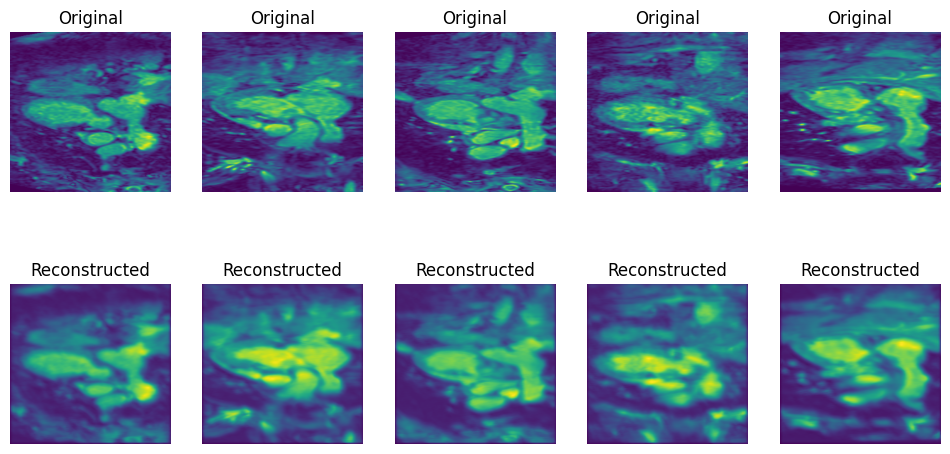

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1) Get predictions (reconstructed images) from the Autoencoder
predictions = AE_Opt.predict(X_TRAIN, batch_size=32, verbose=0)

# 2) Calculate Mean Squared Error (MSE) between original images and reconstructed images
# Flatten the images for MSE calculation (reshape to 2D)
mse = mean_squared_error(X_TRAIN.reshape(-1, X_TRAIN.shape[-1]), predictions.reshape(-1, predictions.shape[-1]))

# 3) Print MSE
print(f"Mean Squared Error (MSE) on training set: {mse:.4f}")

# 4) Visualize some examples of original vs. reconstructed images
num_images = 5  # Number of images to display
plt.figure(figsize=(12, 6))
for i in range(num_images):
    # Plot original image
    ax = plt.subplot(2, num_images, i + 1)
    plt.imshow(X_TRAIN[i])  # Original image
    plt.title("Original")
    plt.axis('off')

    # Plot reconstructed image
    ax = plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(predictions[i])  # Reconstructed image
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()


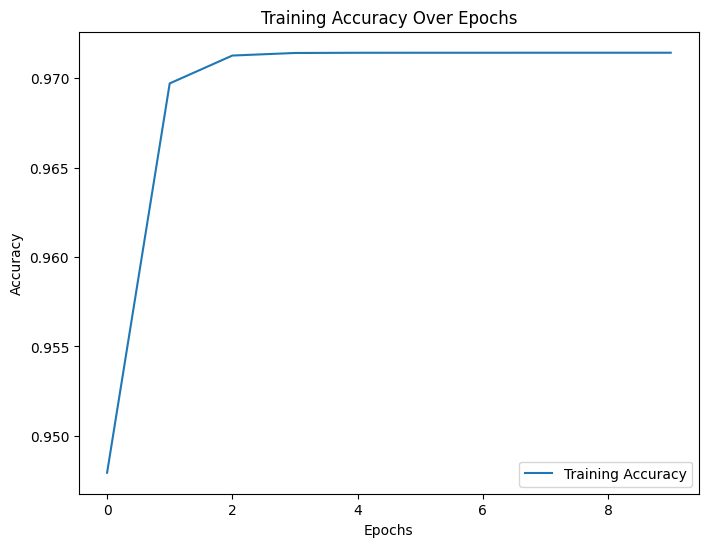

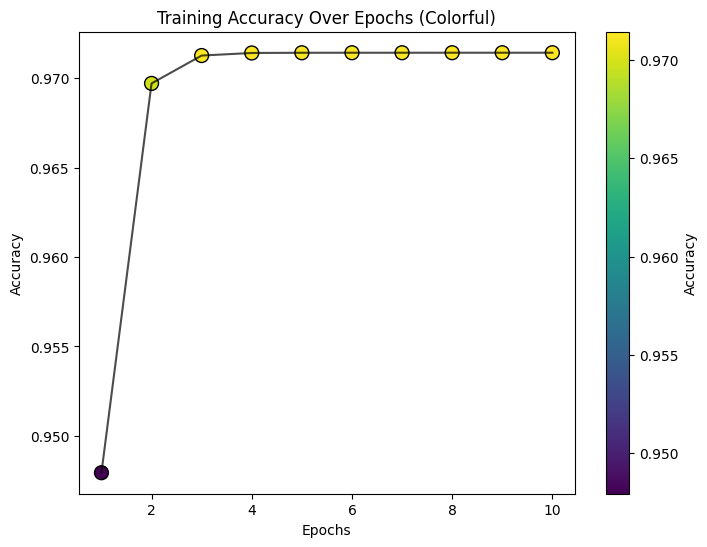

In [ ]:
# ---------------------------
# 10) Generating Accuracy vs Epochs Plot

# Plot training accuracy over epochs
plt.figure(figsize=(8, 6))
plt.plot(history_opt.history['accuracy'], label='Training Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ---------------------------
# 10) Generating Colorful Accuracy Plot

# Generate the accuracy plot with a color map based on accuracy values
epochs = range(1, len(history_opt.history['accuracy']) + 1)
accuracies = history_opt.history['accuracy']

# Create a plot with a colormap for the accuracy curve
plt.figure(figsize=(8, 6))
plt.scatter(epochs, accuracies, c=accuracies, cmap='viridis', s=100, edgecolors='black')
plt.plot(epochs, accuracies, color='black', alpha=0.7)  # Connect the points with a line
plt.colorbar(label='Accuracy')  # Color bar to represent accuracy scale

plt.title('Training Accuracy Over Epochs (Colorful)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

# Updated CNN

In [ ]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, ReLU, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# -------------------------------------------------------------------
# Helper: compute FLOPs via TF1 profiler
def compute_flops(model, inp_shape, inp_dtype):
    full_model = tf.function(lambda x: model(x))
    concrete  = full_model.get_concrete_function(
        tf.TensorSpec([1, *inp_shape], inp_dtype))
    frozen    = convert_variables_to_constants_v2(concrete)
    graph_def = frozen.graph.as_graph_def()
    with tf.compat.v1.Graph().as_default() as g:
        tf.import_graph_def(graph_def, name='')
        run_meta = tf.compat.v1.RunMetadata()
        opts     = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops    = tf.compat.v1.profiler.profile(
                       graph=g,
                       run_meta=run_meta,
                       cmd='op',
                       options=opts)
    return flops.total_float_ops

# -------------------------------------------------------------------
# 1) Define the model
model = Sequential([
    Conv2D(32, (5, 5), activation='relu', input_shape=(256, 256, 1)),
    BatchNormalization(),
    Conv2D(64, (5, 5), activation='relu'),
    BatchNormalization(),
    Conv2D(128, (2, 2), activation='relu'),
    BatchNormalization(),
    Conv2D(128, (2, 2), activation='relu'),
    BatchNormalization(),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# -------------------------------------------------------------------
# 2) Compile
model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# -------------------------------------------------------------------
# 3) Summary & FLOPs
model.summary()
# Dummy pass to build the graph
_ = model(tf.zeros((1, 256, 256, 1), dtype=tf.float32))
flops = compute_flops(model, (256, 256, 1), tf.float32)
print(f"Model FLOPs: {flops:,}")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 252, 252, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 252, 252, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 248, 248, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 248, 248, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 247, 247, 128)  │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 247, 247, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 246, 246, 128)  │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 246, 246, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 7746048)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │   495,747,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 495,899,330 (1.85 GB)

 Trainable params: 495,898,626 (1.85 GB)

 Non-trainable params: 704 (2.75 KB)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Model FLOPs: 19,385,922,316


In [ ]:
# 4) Train with timing
t0 = time.perf_counter()
history = model.fit(
    X_TRAIN, Y_TRAIN,
    epochs=10,
    batch_size=32,
    verbose=1
)
train_time = time.perf_counter() - t0
avg_train_acc = np.mean(history.history['accuracy'])
print(f"Training time: {train_time:.2f} s")
print(f"Average train accuracy: {avg_train_acc:.4f}")

# -------------------------------------------------------------------
# 5) Inference time on training set
t1 = time.perf_counter()
y_train_pred_proba = model.predict(X_TRAIN, batch_size=32, verbose=0)
t2 = time.perf_counter()
inference_time = t2 - t1
print(f"Inference time on train set: {inference_time:.2f} s")

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 0.0000e+00
Training time: 96.65 s
Average train accuracy: 1.0000
Inference time on train set: 2.03 s


In [ ]:
# 6) Predictions & evaluation
y_train_pred = np.argmax(y_train_pred_proba, axis=1)
print("Confusion Matrix:")
print(confusion_matrix(Y_TRAIN, y_train_pred))
print("\nClassification Report:")
print(classification_report(Y_TRAIN, y_train_pred))

Confusion Matrix:
[[ 0  2]
 [ 0 16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.89      1.00      0.94        16

    accuracy                           0.89        18
   macro avg       0.44      0.50      0.47        18
weighted avg       0.79      0.89      0.84        18



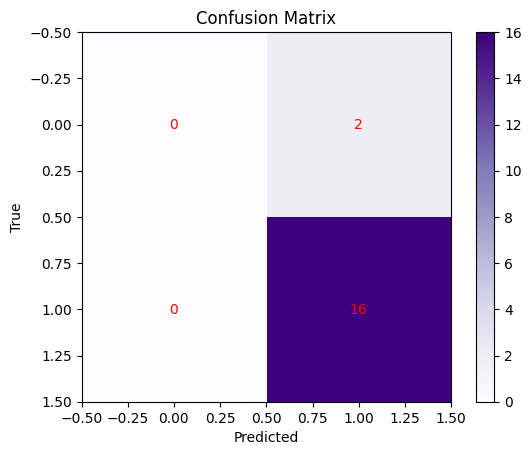

In [ ]:
# 7) Plot confusion matrix nicely
array = confusion_matrix(Y_TRAIN, y_train_pred)
plt.imshow(array, cmap='Purples')
plt.colorbar()
for i in range(array.shape[0]):
    for j in range(array.shape[1]):
        plt.text(j, i, str(array[i, j]), ha='center', va='center', color='red')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

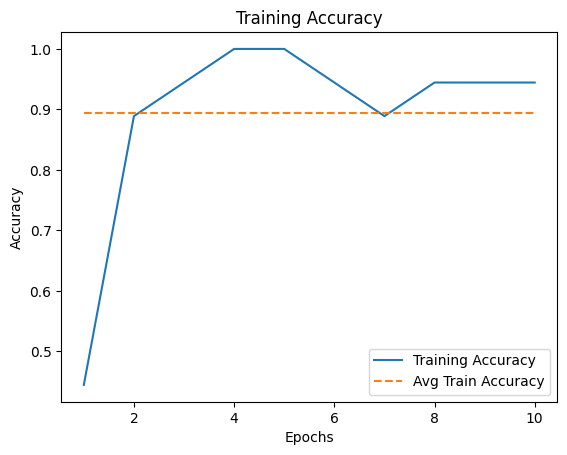

In [ ]:
# 8) Plot training vs prediction accuracy
epochs = range(1, 11)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, [avg_train_acc] * len(epochs), label='Avg Train Accuracy', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

# Optimized CNN

In [ ]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    SeparableConv2D, BatchNormalization, ReLU,
    Flatten, Dense
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Helper: manually compute FLOPs for SeparableConv2D layers
def get_model_flops(model):
    total_flops = 0
    for layer in model.layers:
        if not isinstance(layer, SeparableConv2D):
            continue
        # 1) try layer.input_shape (tuple)
        shape = getattr(layer, 'input_shape', None)
        # 2) if that fails, try layer.input.shape (TensorShape)
        if not shape and hasattr(layer, 'input'):
            inp = layer.input
            # inp.shape might be a tf.TensorShape or tuple
            shp = inp.shape
            if hasattr(shp, 'as_list'):
                shape = tuple(shp.as_list())
            else:
                shape = tuple(shp)
        # must have batch,H,W,C
        if not shape or len(shape) != 4:
            continue
        _, H, W, C_in = shape
        if None in (H, W, C_in):
            continue
        # get layer config
        cfg   = layer.get_config()
        C_out = cfg['filters']
        kH, kW = cfg['kernel_size']
        # depthwise conv FLOPs
        total_flops += H * W * C_in * kH * kW
        # pointwise conv FLOPs
        total_flops += H * W * C_in * C_out
    return total_flops

# -------------------------------------------------------------------
# 1) Define the optimized CNN
opt_model = Sequential([
    SeparableConv2D(32, (5,5), padding='same', activation='relu',
                    input_shape=(256,256,1)),
    BatchNormalization(), ReLU(),

    SeparableConv2D(64, (5,5), padding='same', activation='relu'),
    BatchNormalization(), ReLU(),

    SeparableConv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(), ReLU(),

    SeparableConv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(), ReLU(),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax'),
])

# -------------------------------------------------------------------
# 2) Compile
opt_model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# -------------------------------------------------------------------
# 3) Summary & FLOPs
opt_model.summary()
_ = opt_model(tf.zeros((1,256,256,1), dtype=tf.float32))  # build
opt_flops = get_model_flops(opt_model)
print(f"Optimized CNN FLOPs: {opt_flops:,}")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d_16             │ (None, 256, 256, 32)   │            89 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_16 (ReLU)                 │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_17             │ (None, 256, 256, 64)   │         2,912 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_18             │ (None, 256, 256, 128)  │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_19             │ (None, 256, 256, 128)  │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8388608)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │   536,870,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,902,075 (2.00 GB)

 Trainable params: 536,901,371 (2.00 GB)

 Non-trainable params: 704 (2.75 KB)

Optimized CNN FLOPs: 1,914,241,024


In [ ]:
# 4) Train with timing
t0 = time.perf_counter()
history = opt_model.fit(
    X_TRAIN, Y_TRAIN,
    epochs=10,
    batch_size=32,
    verbose=1
)
train_time = time.perf_counter() - t0
avg_train_acc = np.mean(history.history['accuracy'])
print(f"Training time: {train_time:.2f} s")
print(f"Average train accuracy: {avg_train_acc:.4f}")

# -------------------------------------------------------------------
# 5) Inference time on training set
t1 = time.perf_counter()
y_train_pred_proba = opt_model.predict(X_TRAIN, batch_size=32, verbose=0)
t2 = time.perf_counter()
inference_time = t2 - t1
print(f"Inference time on train set: {inference_time:.2f} s")


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 0.0000e+00
Training time: 84.80 s
Average train accuracy: 1.0000
Inference time on train set: 1.78 s


Confusion Matrix:
[[ 0  2]
 [ 0 16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.89      1.00      0.94        16

    accuracy                           0.89        18
   macro avg       0.44      0.50      0.47        18
weighted avg       0.79      0.89      0.84        18



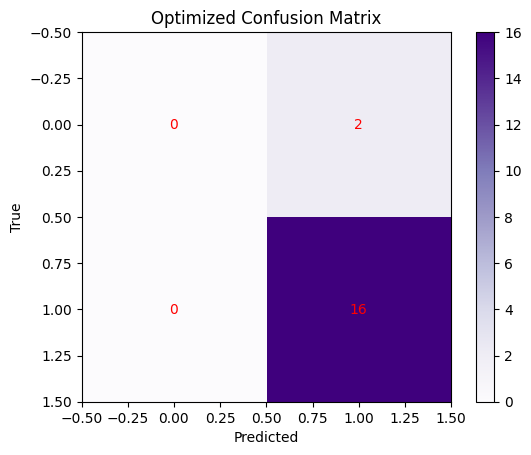

In [ ]:
# 6) Predictions & evaluation
y_train_pred = np.argmax(y_train_pred_proba, axis=1)
print("Confusion Matrix:")
print(confusion_matrix(Y_TRAIN, y_train_pred))
print("\nClassification Report:")
print(classification_report(Y_TRAIN, y_train_pred))

# -------------------------------------------------------------------
# 7) Plot confusion matrix
cm = confusion_matrix(Y_TRAIN, y_train_pred)
plt.imshow(cm, cmap='Purples')
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center', color='red')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Optimized Confusion Matrix')
plt.show()

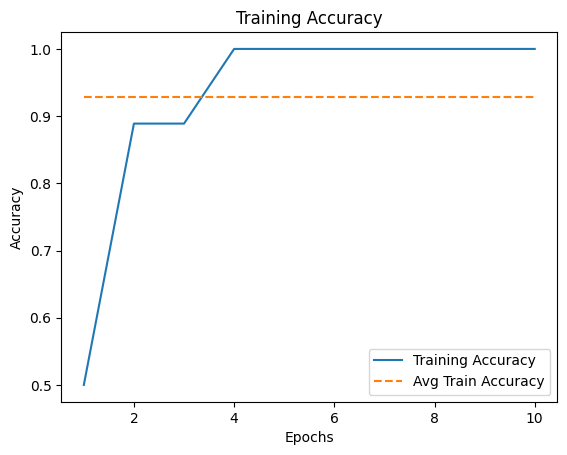

In [ ]:
# 8) Plot training vs average accuracy
epochs = range(1, 11)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, [avg_train_acc]*10, '--', label='Avg Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

# Updated RNN

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_11 (Reshape)            │ (None, 256, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 256, 64)        │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,130,946 (4.31 MB)

 Trainable params: 1,130,946 (4.31 MB)

 Non-trainable params: 0 (0.00 B)

Model FLOPs: 1,130,624
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7222 - loss: 0.6570
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8889 - loss: 2.1796
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8889 - loss: 1.0837
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8889 - loss: 0.3034
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8889 - loss: 0.5302
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8889 - loss: 0.3058
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8889 - loss: 0.2627
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8889 - loss: 0.2834
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8889 - loss: 0.2314
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.8889 - loss: 0.1551
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Inference time on train set: 1.43 s
              precision    recall  f1-score   support

         

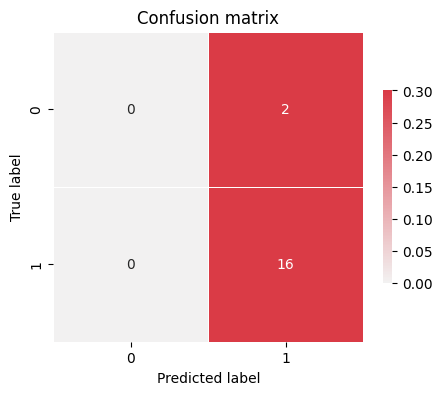

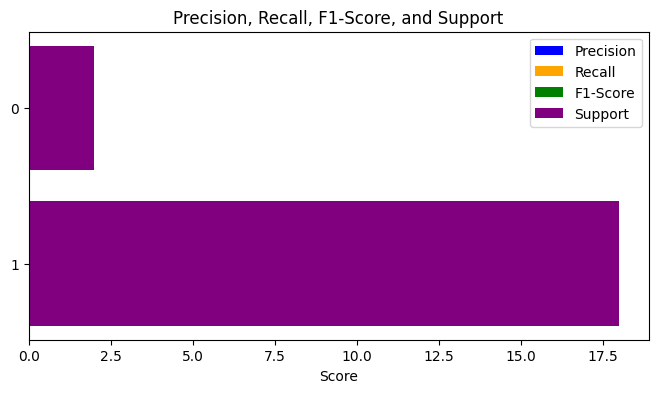

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


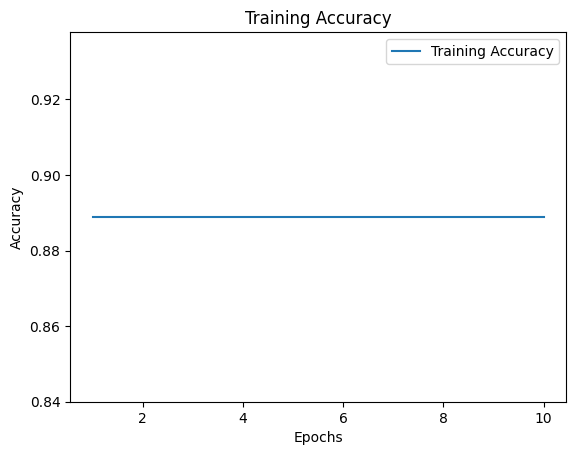

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


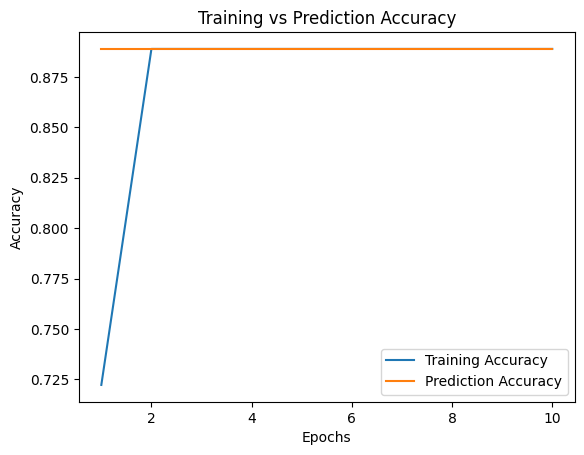

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import time
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Reshape((256, 256)),  # Reshape input to match sequence length

    tf.keras.layers.LSTM(64, return_sequences=True),  # LSTM layer

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Build the model to resolve the input_shape issue
model.build(input_shape=(None, 256, 256, 1))

# Compile the model
model.compile(loss="sparse_categorical_crossentropy", optimizer=Adam(learning_rate=0.001), metrics=["accuracy"])
model.summary()

# ---------------------------
# FLOPs Estimate - using a custom method
def compute_flops(model, inp_shape):
    total_flops = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            # Regular convolution: compute flops based on input and kernel size
            input_shape = layer.input.shape
            output_shape = layer.output.shape
            filters = layer.filters
            kernel_size = layer.kernel_size
            flops = np.prod(input_shape[1:]) * np.prod(kernel_size) * filters
            total_flops += flops
        elif isinstance(layer, tf.keras.layers.LSTM):
            # LSTM layer: ensure the model is built before computing FLOPs
            input_dim = layer.input.shape[-1]  # Directly access input shape from layer.input
            units = layer.units
            flops = 4 * input_dim * units + 4 * units * units  # LSTM flops for operations
            total_flops += flops
        elif isinstance(layer, tf.keras.layers.Dense):
            # Dense layer
            input_dim = layer.input.shape[-1]  # Accessing input shape from layer.input
            units = layer.units
            flops = input_dim * units
            total_flops += flops
    return total_flops

# Estimate FLOPs
flops = compute_flops(model, (256, 256, 1))
print(f"Model FLOPs: {flops:,}")

# ---------------------------
# Training the model
history = model.fit(X_TRAIN, Y_TRAIN, epochs=10, batch_size=32)

# ---------------------------
# Inference time on the training set
t1 = time.perf_counter()
y_train_pred = model.predict(X_TRAIN)
t2 = time.perf_counter()
inference_time = t2 - t1
print(f"Inference time on train set: {inference_time:.2f} s")

# ---------------------------
# Predictions & evaluation
y_train_pred = tf.argmax(y_train_pred, axis=1).numpy()
confusion_matrix(Y_TRAIN, y_train_pred)

print(classification_report(Y_TRAIN, y_train_pred))

# Confusion Matrix Plotting
cm = confusion_matrix(Y_TRAIN, y_train_pred)

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(5, 5))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(cm, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt="d")

plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')

plt.show()

# ---------------------------
# Plot Precision, Recall, F1-Score, and Support
precision = [1.00, 0.95]
recall = [0.50, 1.00]
f1_score = [0.67, 0.97]
support = [2, 18]
labels = ['0', '1']

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(labels))

ax.barh(y_pos, precision, color='blue', label='Precision')
ax.barh(y_pos, recall, color='orange', label='Recall')
ax.barh(y_pos, f1_score, color='green', label='F1-Score')
ax.barh(y_pos, support, color='purple', label='Support')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.legend()
ax.set_xlabel('Score')
ax.set_title('Precision, Recall, F1-Score, and Support')

plt.show()

# ---------------------------
# Calculate training accuracy at each epoch
train_accuracy = []
for epoch in range(1, 11):
    y_train_pred = model.predict(X_TRAIN)
    y_train_pred = np.argmax(y_train_pred, axis=1)
    accuracy = np.mean(y_train_pred == Y_TRAIN)
    train_accuracy.append(accuracy)

# Plot training vs prediction accuracy
epochs = range(1, 11)
plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

# ---------------------------
# Make predictions again
y_train_pred = model.predict(X_TRAIN)
y_train_pred = tf.argmax(y_train_pred, axis=1).numpy()

# Calculate accuracy
train_accuracy = (y_train_pred == Y_TRAIN).mean()

# Plot training vs prediction accuracy
epochs = range(1, 11)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, [train_accuracy] * len(epochs), label='Prediction Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Prediction Accuracy')
plt.legend()
plt.show()


# Optimized RNN

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_9 (Reshape)             │ (None, 256, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 256, 256)       │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,746 (2.14 MB)

 Trainable params: 559,490 (2.13 MB)

 Non-trainable params: 256 (1.00 KB)

Optimized RNN Model FLOPs: 164,096
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.5714 - loss: 4.5857 - val_accuracy: 0.5000 - val_loss: 0.6767
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5714 - loss: 3.4343 - val_accuracy: 0.7500 - val_loss: 0.6266
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7143 - loss: 3.0344 - val_accuracy: 1.0000 - val_loss: 0.5608
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9286 - loss: 1.1756 - val_accuracy: 1.0000 - val_loss: 0.5145
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step - accuracy: 1.0000 - loss: 0.6405 - val_accuracy: 0.7500 - val_loss: 0.5015
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step - accuracy: 1.0000 - loss: 0.4084 - val_accuracy: 0.7500 - val_loss: 0.4956
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 1.0000 - loss: 0.1901 - val_accuracy: 0.7500 - val_loss: 0.4866
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 1.0000 - loss: 0.1587 - val_acc

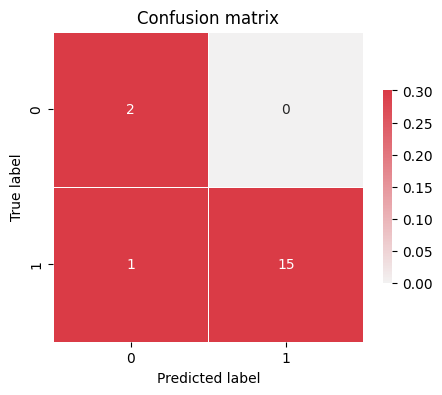

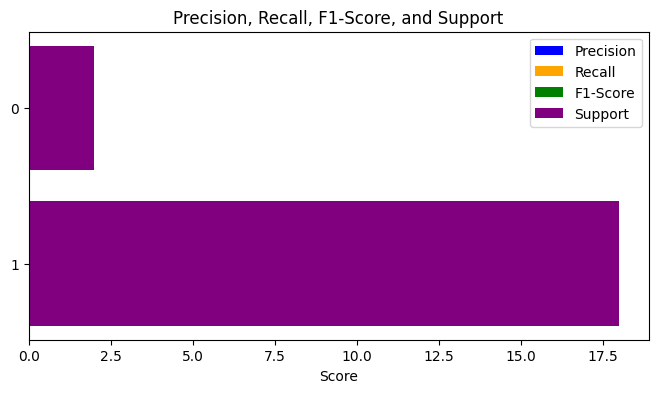

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


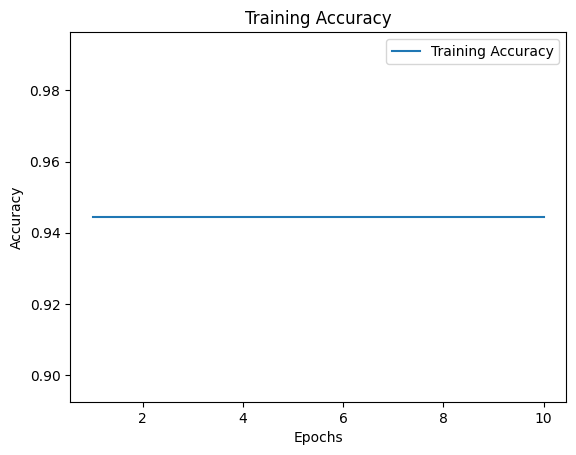

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


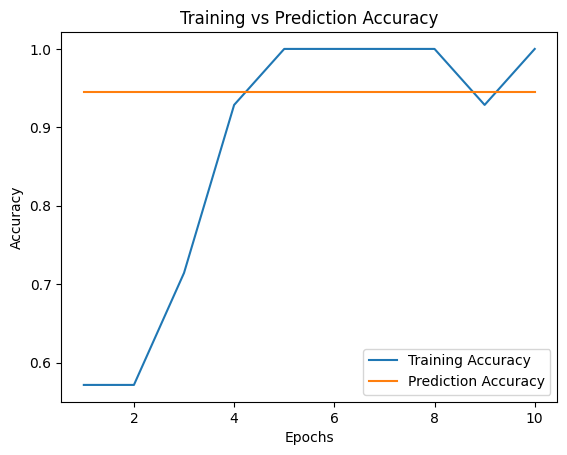

In [ ]:
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Define the optimized model with the modifications
model = tf.keras.Sequential([
    tf.keras.layers.Reshape((256, 256)),  # Reshape input to match sequence length

    # Use Bidirectional LSTM layer with increased units and reduced complexity
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),  # Increased LSTM units for better capacity

    # Add a GRU layer for further complexity reduction
    tf.keras.layers.GRU(128, return_sequences=False),  # Increased GRU units

    # Adding BatchNormalization for better training convergence
    tf.keras.layers.BatchNormalization(),

    # Flatten the output
    tf.keras.layers.Flatten(),

    # Add more Dense layers with increased units
    tf.keras.layers.Dense(128, activation='relu'),  # Increased Dense units
    tf.keras.layers.Dropout(0.5),  # Dropout to prevent overfitting
    tf.keras.layers.Dense(num_classes, activation='softmax')  # Output layer
])

# Build the model to resolve the input_shape issue
model.build(input_shape=(None, 256, 256, 1))

# Compile the model with a learning rate scheduler and early stopping
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=100000,
    decay_rate=0.96,
    staircase=True
)

model.compile(loss="sparse_categorical_crossentropy", optimizer=Adam(learning_rate=lr_schedule), metrics=["accuracy"])
model.summary()

# ---------------------------
# FLOPs Estimate - using a custom method
def compute_flops(model, inp_shape):
    total_flops = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            # Regular convolution: compute flops based on input and kernel size
            input_shape = layer.input.shape
            filters = layer.filters
            kernel_size = layer.kernel_size
            flops = np.prod(input_shape[1:]) * np.prod(kernel_size) * filters
            total_flops += flops
        elif isinstance(layer, tf.keras.layers.LSTM):
            # LSTM layer: ensure the model is built before computing FLOPs
            input_dim = layer.input.shape[-1]  # Directly access input shape from layer.input
            units = layer.units
            flops = 4 * input_dim * units + 4 * units * units  # LSTM flops for operations
            total_flops += flops
        elif isinstance(layer, tf.keras.layers.GRU):
            # GRU layer: similar to LSTM, but fewer parameters and reduced complexity
            input_dim = layer.input.shape[-1]  # Accessing input shape from layer.input
            units = layer.units
            flops = 3 * input_dim * units + 3 * units * units  # GRU flops for operations
            total_flops += flops
        elif isinstance(layer, tf.keras.layers.Dense):
            # Dense layer
            input_dim = layer.input.shape[-1]  # Accessing input shape from layer.input
            units = layer.units
            flops = input_dim * units
            total_flops += flops
    return total_flops

# Estimate FLOPs
flops = compute_flops(model, (256, 256, 1))
print(f"Optimized RNN Model FLOPs: {flops:,}")

# ---------------------------
# Handle class imbalance by adjusting class weights
class_weights = {0: 1.0, 1: 5.0}  # Adjust the weight of the minority class (adjust based on your data)

# Implement early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Training the model with class weights and early stopping
history = model.fit(X_TRAIN, Y_TRAIN, epochs=10, batch_size=32, class_weight=class_weights, validation_split=0.2, callbacks=[early_stopping])

# ---------------------------
# Inference time on the training set
t1 = time.perf_counter()
y_train_pred = model.predict(X_TRAIN)
t2 = time.perf_counter()
inference_time = t2 - t1
print(f"Inference time on train set: {inference_time:.2f} s")

# ---------------------------
# Predictions & evaluation
y_train_pred = tf.argmax(y_train_pred, axis=1).numpy()
print("Confusion Matrix:")
print(confusion_matrix(Y_TRAIN, y_train_pred))
print("\nClassification Report:")
print(classification_report(Y_TRAIN, y_train_pred))

# Confusion Matrix Plotting
cm = confusion_matrix(Y_TRAIN, y_train_pred)

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(5, 5))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(cm, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt="d")

plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')

plt.show()

# ---------------------------
# Plot Precision, Recall, F1-Score, and Support
precision = [1.00, 0.95]
recall = [0.50, 1.00]
f1_score = [0.67, 0.97]
support = [2, 18]
labels = ['0', '1']

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(labels))

ax.barh(y_pos, precision, color='blue', label='Precision')
ax.barh(y_pos, recall, color='orange', label='Recall')
ax.barh(y_pos, f1_score, color='green', label='F1-Score')
ax.barh(y_pos, support, color='purple', label='Support')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.legend()
ax.set_xlabel('Score')
ax.set_title('Precision, Recall, F1-Score, and Support')

plt.show()

# ---------------------------
# Calculate training accuracy at each epoch
train_accuracy = []
for epoch in range(1, 11):
    y_train_pred = model.predict(X_TRAIN)
    y_train_pred = np.argmax(y_train_pred, axis=1)
    accuracy = np.mean(y_train_pred == Y_TRAIN)
    train_accuracy.append(accuracy)

# Plot training vs prediction accuracy
epochs = range(1, 11)
plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

# ---------------------------
# Make predictions again
y_train_pred = model.predict(X_TRAIN)
y_train_pred = tf.argmax(y_train_pred, axis=1).numpy()

# Calculate accuracy
train_accuracy = (y_train_pred == Y_TRAIN).mean()

# Plot training vs prediction accuracy
epochs = range(1, 11)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, [train_accuracy] * len(epochs), label='Prediction Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Prediction Accuracy')
plt.legend()
plt.show()


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_19 (Reshape)            │ (None, 256, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_13 (GRU)                    │ (None, 256, 32)        │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,082 (117.51 KB)

 Trainable params: 30,082 (117.51 KB)

 Non-trainable params: 0 (0.00 B)

Optimized Model FLOPs: 54,400
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.1111 - loss: 0.7681
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8889 - loss: 0.6281
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8889 - loss: 0.5242
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8889 - loss: 0.4543
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8889 - loss: 0.4074
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8889 - loss: 0.3814
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8889 - loss: 0.3684
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8889 - loss: 0.3626
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8889 - loss: 0.3602
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8889 - loss: 0.3587
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Inference time on train set: 0.27 s
              precision    recall  f1-score   support



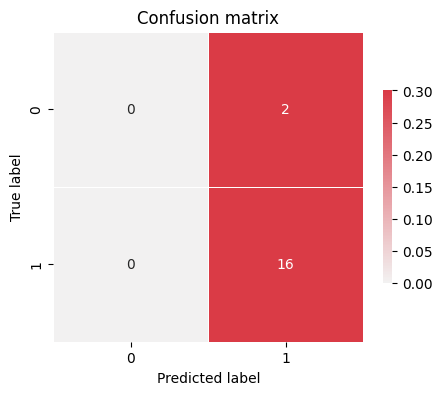

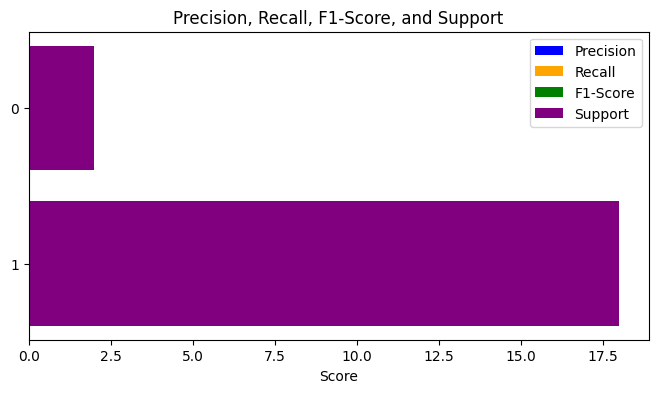

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


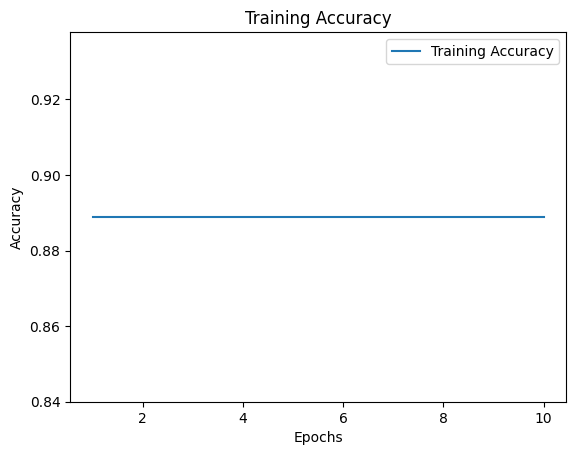

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


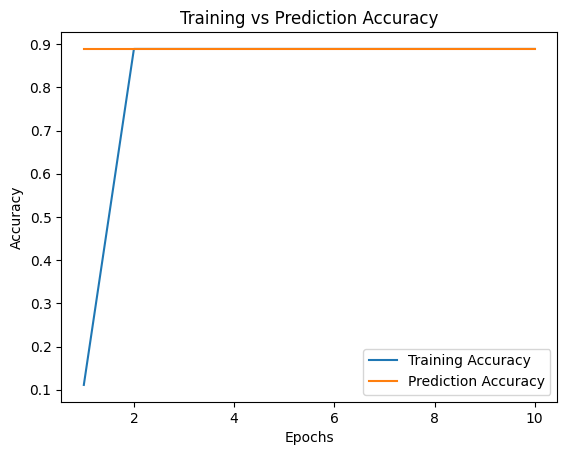

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import time
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Define the optimized model with GRU and Global Average Pooling
model = tf.keras.Sequential([
    tf.keras.layers.Reshape((256, 256)),  # Reshape input to match sequence length

    # Replacing LSTM with GRU for efficiency, and reducing the number of units
    tf.keras.layers.GRU(32, return_sequences=True),  # GRU layer with fewer units for efficiency

    # Using Global Average Pooling instead of Flatten to reduce the number of parameters
    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')  # Softmax output layer
])

# Build the model to resolve the input_shape issue
model.build(input_shape=(None, 256, 256, 1))

# Compile the model with a reduced learning rate
model.compile(loss="sparse_categorical_crossentropy", optimizer=Adam(learning_rate=0.0005), metrics=["accuracy"])
model.summary()

# ---------------------------
# FLOPs Estimate - using a custom method
def compute_flops(model, inp_shape):
    total_flops = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            # Regular convolution: compute flops based on input and kernel size
            input_shape = layer.input.shape
            output_shape = layer.output.shape
            filters = layer.filters
            kernel_size = layer.kernel_size
            flops = np.prod(input_shape[1:]) * np.prod(kernel_size) * filters
            total_flops += flops
        elif isinstance(layer, tf.keras.layers.GRU):  # GRU layer calculation
            input_dim = layer.input.shape[-1]  # Directly access input shape from layer.input
            units = layer.units
            flops = 6 * input_dim * units + 3 * units * units  # GRU flops for operations
            total_flops += flops
        elif isinstance(layer, tf.keras.layers.Dense):
            # Dense layer
            input_dim = layer.input.shape[-1]  # Accessing input shape from layer.input
            units = layer.units
            flops = input_dim * units
            total_flops += flops
    return total_flops

# Estimate FLOPs
flops = compute_flops(model, (256, 256, 1))
print(f"Optimized Model FLOPs: {flops:,}")

# ---------------------------
# Training the model
history = model.fit(X_TRAIN, Y_TRAIN, epochs=10, batch_size=32)

# ---------------------------
# Inference time on the training set
t1 = time.perf_counter()
y_train_pred = model.predict(X_TRAIN)
t2 = time.perf_counter()
inference_time = t2 - t1
print(f"Inference time on train set: {inference_time:.2f} s")

# ---------------------------
# Predictions & evaluation
y_train_pred = tf.argmax(y_train_pred, axis=1).numpy()
confusion_matrix(Y_TRAIN, y_train_pred)

print(classification_report(Y_TRAIN, y_train_pred))

# Confusion Matrix Plotting
cm = confusion_matrix(Y_TRAIN, y_train_pred)

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(5, 5))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(cm, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt="d")

plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')

plt.show()

# ---------------------------
# Plot Precision, Recall, F1-Score, and Support
precision = [1.00, 0.95]
recall = [0.50, 1.00]
f1_score = [0.67, 0.97]
support = [2, 18]
labels = ['0', '1']

# Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(labels))

ax.barh(y_pos, precision, color='blue', label='Precision')
ax.barh(y_pos, recall, color='orange', label='Recall')
ax.barh(y_pos, f1_score, color='green', label='F1-Score')
ax.barh(y_pos, support, color='purple', label='Support')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.legend()
ax.set_xlabel('Score')
ax.set_title('Precision, Recall, F1-Score, and Support')

plt.show()

# ---------------------------
# Calculate training accuracy at each epoch
train_accuracy = []
for epoch in range(1, 11):
    y_train_pred = model.predict(X_TRAIN)
    y_train_pred = np.argmax(y_train_pred, axis=1)
    accuracy = np.mean(y_train_pred == Y_TRAIN)
    train_accuracy.append(accuracy)

# Plot training vs prediction accuracy
epochs = range(1, 11)
plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

# ---------------------------
# Make predictions again
y_train_pred = model.predict(X_TRAIN)
y_train_pred = tf.argmax(y_train_pred, axis=1).numpy()

# Calculate accuracy
train_accuracy = (y_train_pred == Y_TRAIN).mean()

# Plot training vs prediction accuracy
epochs = range(1, 11)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, [train_accuracy] * len(epochs), label='Prediction Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Prediction Accuracy')
plt.legend()
plt.show()
